# Grip Flight：operator 数据契约、连续窗口与事件锁定特征表

这个笔记本使用 `seeg-operator-workbench` 的通用数据契约和 Grip Flight 项目适配器，生成两张互不混淆的数据表：

1. `continuous_feature_table`：连续训练窗口，用于 EEG 特征与力/力斜率的关系。
2. `event_feature_table`：事件锁定训练窗口，用于 exertion、relaxation、hold 的相对时间动态。

约束：最后一个完整 trial 是 test；所有当前特征、事件等级阈值和 QC 阈值只使用 train。任何跨通道聚合仍然禁止，除非用户以后明确同意。

## 1. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import signal, stats

HELPER_DIR = Path(r"/Users/heting/Documents/readGripData")
OPERATOR_SRC = Path(r"/Users/heting/Documents/seeg-operator-workbench/src")
for local_path in (HELPER_DIR, OPERATOR_SRC):
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))

from operator_adapters import GripFlightAdapter
from seegops import (
    BandFeatureSpec,
    ContinuousWindowSampler,
    EventLockedSampler,
    FeatureBank,
    FeatureCollection,
    FeatureTableAssembler,
    ForceTargetBank,
    Pipeline,
    SampleTable,
    TrialSignalProvider,
)
from seegops.operators import NotchFilter, Select
from seegops.qc import channel_qc_from_trials, sample_qc_from_features

# ==================== Data selection ====================
DATA_DIR = Path(r"/Users/heting/Documents/20260817_HHFU202")
RUN_NAME = "testS001R14"
N_TEST_TRIALS = 1
# ========================================================

CONTINUOUS_WINDOW_S = 2.0
CONTINUOUS_STEP_S = 0.25

EVENT_TMIN_S = -1.0
EVENT_TMAX_S = 2.0
# Two-second event windows preserve the four-cycle constraint at 2 Hz.
EVENT_WINDOW_S = 2.0
EVENT_STEP_S = 0.25

LINE_FREQUENCY_HZ = 50.0
NOTCH_FREQUENCIES_HZ = (50.0, 100.0, 150.0, 200.0, 250.0)
NOTCH_Q = 30.0
PSD_AUDIT_CHANNEL_COUNT = 8

OUTPUT_DIR = HELPER_DIR / "feature_outputs"
SAVE_TABLES = True

FREQUENCY_BANDS = (
    BandFeatureSpec("delta_2_4", 2.0, 4.0, minimum_cycles=4.0),
    BandFeatureSpec("theta_4_8", 4.0, 8.0, minimum_cycles=4.0),
    BandFeatureSpec("alpha_8_12", 8.0, 12.0, minimum_cycles=4.0),
    BandFeatureSpec("beta_14_30", 14.0, 30.0, minimum_cycles=4.0),
    BandFeatureSpec("low_gamma_30_80", 30.0, 80.0, minimum_cycles=4.0),
    BandFeatureSpec("high_gamma_80_160", 80.0, 160.0, minimum_cycles=4.0),
    BandFeatureSpec("ultra_gamma_160_240", 160.0, 240.0, minimum_cycles=4.0),
)

print("Channel reduction is disabled in FeatureBank.")
print("Parquet and standalone manifest are intentionally deferred.")

Channel reduction is disabled in FeatureBank.
Parquet and standalone manifest are intentionally deferred.


## 2. Adapt BCI2000 data to Signal, TrialTable and EventTable

In [2]:
adapter = GripFlightAdapter(
    data_dir=DATA_DIR,
    run_name=RUN_NAME,
    n_test_trials=N_TEST_TRIALS,
    force_channel_index=0,
    minimum_hold_duration_s=0.25,
    minimum_force_change=0.05,
    minimum_change_duration_s=0.20,
)
recording = adapter.load()

print("Available runs:", recording.available_runs)
print("EEG source:", recording.eeg_path)
print("Task source:", recording.task_path)
print("EEG Signal:", recording.eeg.dims, recording.eeg.data.shape)
print("Force Signal:", recording.force.dims, recording.force.data.shape)
print("Event policy fitted from training trials:", recording.event_policy)

Available runs: ('testS001R13', 'testS001R14', 'testS001R15', 'testS001R16', 'testS001R16a')
EEG source: /Users/heting/Documents/20260817_HHFU202/testS001R14.dat
Task source: /Users/heting/Documents/20260817_HHFU202/testS001R14_1.dat
EEG Signal: ('channel', 'time') (272, 969600)
Force Signal: ('time',) (969600,)
Event policy fitted from training trials: {'force_range': (0.8626225999780073, 0.9754682598929365), 'force_mean_train': 0.9190454299354719, 'force_sigma_train': 0.05642282995746456, 'minimum_hold_duration_s': 0.25, 'minimum_force_change': 0.05, 'minimum_change_duration_s': 0.2, 'amplitude_grade_edges': (0.078000009059906, 0.13199996948242188), 'grade_source': 'training exertion amplitude tertiles'}


In [3]:
trial_frame = pd.DataFrame(recording.trials.as_records())
event_frame = pd.DataFrame(recording.events.as_records())

display(trial_frame)
display(
    event_frame.groupby(["event_type", "label", "split"], observed=True)
    .agg(count=("event_id", "size"), median_amplitude=("amplitude", "median"))
    .reset_index()
)

train_trial_ids = trial_frame.loc[trial_frame["split"] == "train", "trial_id"].tolist()
test_trial_ids = trial_frame.loc[trial_frame["split"] == "test", "trial_id"].tolist()
print("Train trials:", train_trial_ids)
print("Held-out test trials:", test_trial_ids)
assert train_trial_ids and test_trial_ids

,trial_id,onset_s,offset_s,condition,valid,recording,trial_number,split,task_start_sample,task_stop_sample_exclusive,eeg_start_sample,eeg_stop_sample_exclusive
0,testS001R14-trial-001,1.198,49.1965,None,True,testS001R14,1,train,288,12576,2396,98393
1,testS001R14-trial-002,49.200,97.1955,None,True,testS001R14,2,train,12576,24864,98400,194391
2,testS001R14-trial-003,97.199,145.1965,None,True,testS001R14,3,train,24864,37152,194398,290393
3,testS001R14-trial-004,145.200,193.1945,None,True,testS001R14,4,train,37152,49440,290400,386389
4,testS001R14-trial-005,193.198,241.1955,None,True,testS001R14,5,train,49440,61728,386396,482391
5,testS001R14-trial-006,241.199,289.1975,None,True,testS001R14,6,train,61728,74016,482398,578395
6,testS001R14-trial-007,289.201,337.2045,None,True,testS001R14,7,train,74016,86304,578402,674409
7,testS001R14-trial-008,337.208,385.1995,None,True,testS001R14,8,train,86304,98592,674416,770399
8,testS001R14-trial-009,385.203,433.2055,None,True,testS001R14,9,train,98592,110880,770406,866411
9,testS001R14-trial-010,433.209,480.0855,None,True,testS001R14,10,test,110880,122912,866418,960171


,event_type,label,split,count,median_amplitude
0,exertion,exertion_large,test,7,0.1810
1,exertion,exertion_large,train,42,0.2175
2,exertion,exertion_medium,test,4,0.0905
3,exertion,exertion_medium,train,43,0.0980
4,exertion,exertion_small,test,4,0.0730
5,exertion,exertion_small,train,44,0.0680
6,hold,hold_in_range,test,11,0.0780
7,hold,hold_in_range,train,95,0.0780
8,relaxation,relaxation_large,test,6,0.2395
9,relaxation,relaxation_large,train,45,0.2050


Train trials: ['testS001R14-trial-001', 'testS001R14-trial-002', 'testS001R14-trial-003', 'testS001R14-trial-004', 'testS001R14-trial-005', 'testS001R14-trial-006', 'testS001R14-trial-007', 'testS001R14-trial-008', 'testS001R14-trial-009']
Held-out test trials: ['testS001R14-trial-010']


## 3. Shared trial-level preprocessing and QC

`TrialSignalProvider` lazily reads one trial, selects SEEG channels, applies notch once, and caches that processed trial while all continuous/event samples belonging to it are computed. Both paths therefore use identical preprocessing without concatenating trials or crossing trial boundaries.

In [4]:
seeg_source_indices = recording.seeg_channel_indices()
seeg_names = recording.eeg.coordinate("channel")[seeg_source_indices]
preprocessing = (
    Pipeline()
    .then(Select(dim="channel", indices=seeg_source_indices))
    .then(NotchFilter(
        frequencies_hz=NOTCH_FREQUENCIES_HZ,
        quality_factor=NOTCH_Q,
        trace_batch_size=32,
    ))
)
provider = TrialSignalProvider(
    signal=recording.eeg,
    trials=recording.trials,
    preprocessing=preprocessing,
)
raw_selected_provider = TrialSignalProvider(
    signal=recording.eeg,
    trials=recording.trials,
    preprocessing=Pipeline().then(Select(dim="channel", indices=seeg_source_indices)),
)

channel_qc = channel_qc_from_trials(
    provider,
    trial_ids=train_trial_ids,
    recording_id=recording.recording_id,
    seconds_per_trial=10.0,
    line_frequencies_hz=NOTCH_FREQUENCIES_HZ,
)
print("Retained SEEG channels:", len(seeg_source_indices))
display(channel_qc.frame.channel_qc_valid.value_counts(dropna=False).rename("channels"))
display(channel_qc.frame.loc[~channel_qc.frame.channel_qc_valid].head(30))

Retained SEEG channels: 188


channel_qc_valid
True     187
False      1
Name: channels, dtype: int64

,recording,channel_index,source_channel_index,channel,channel_qc_finite_fraction,channel_qc_rms,channel_qc_peak_to_peak,channel_qc_rms_robust_z,channel_qc_line_noise_ratio,channel_qc_valid,channel_qc_reason
52,testS001R14,52,52,B4,1.0,163.672551,1619.108276,8.241141,0.940425,False,rms_outlier


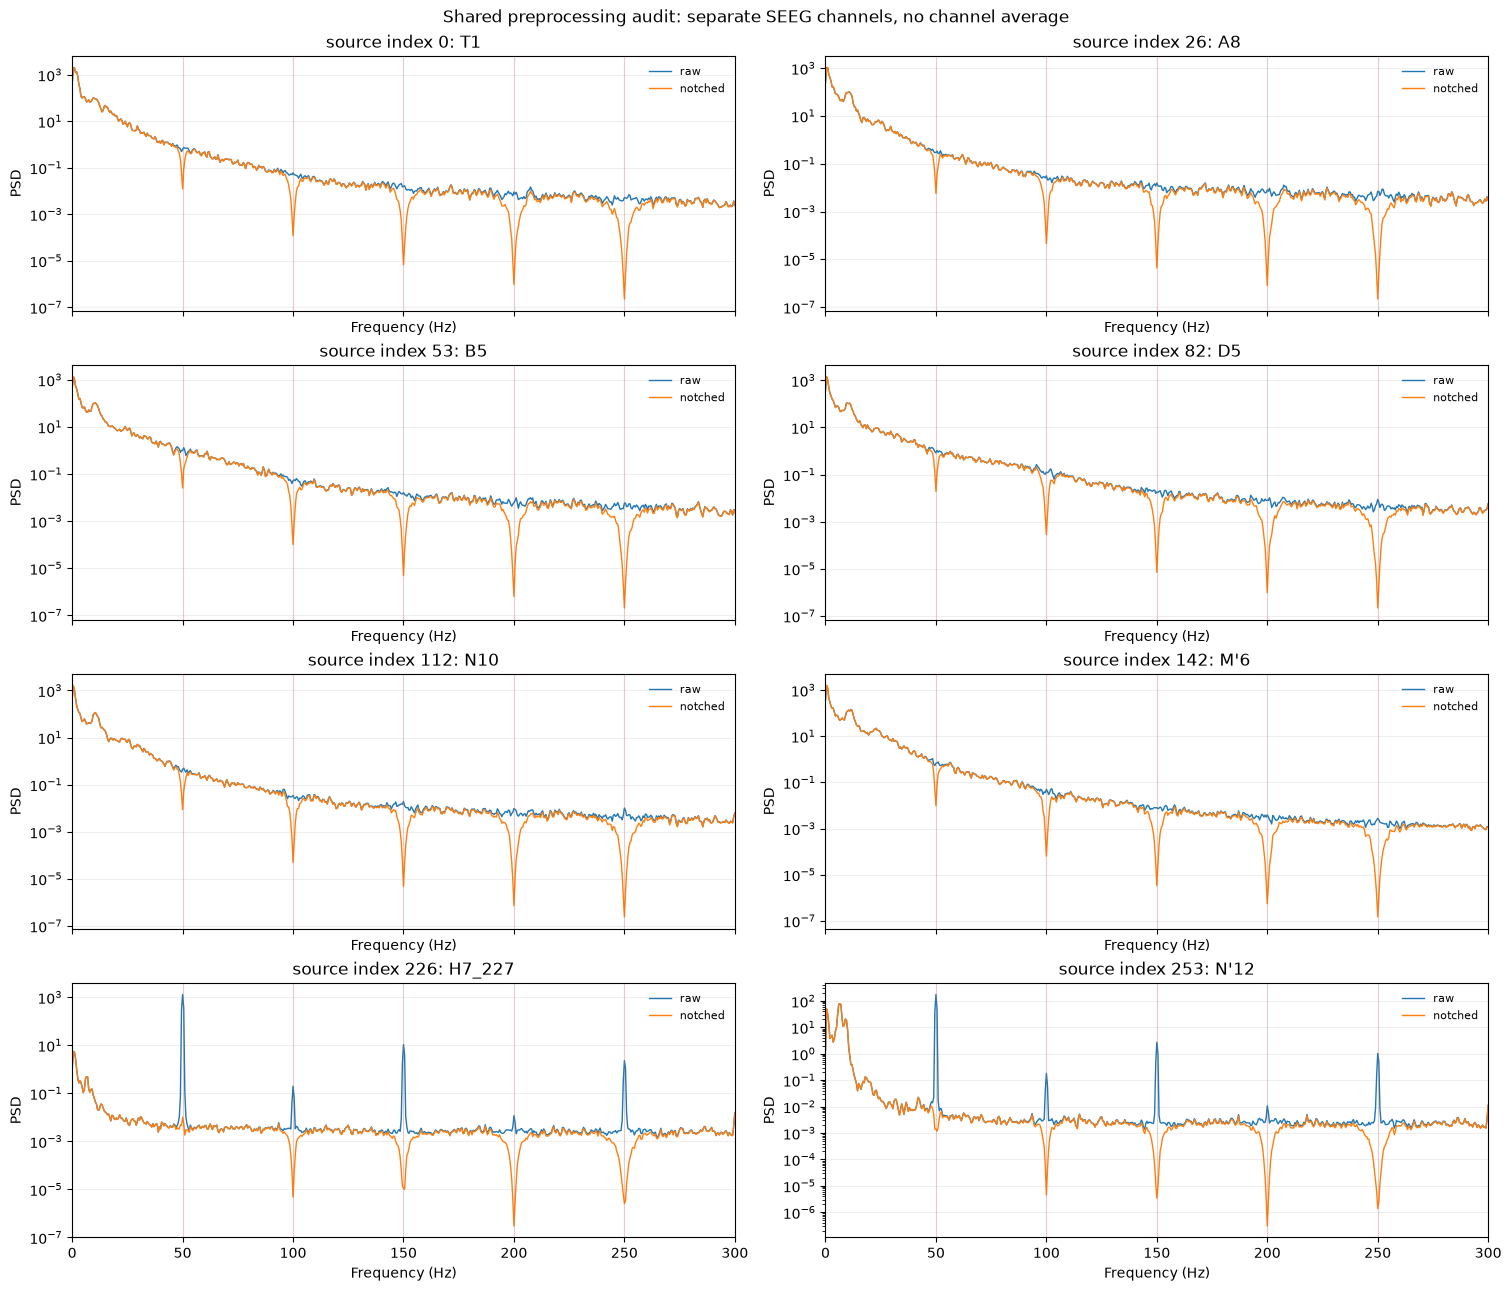

,source_channel_index,channel
0,0,T1
1,26,A8
2,53,B5
3,82,D5
4,112,N10
5,142,M'6
6,226,H7_227
7,253,N'12


In [5]:
# Multi-channel PSD audit; every subplot is one channel and no channel average is used.
audit_positions = np.linspace(
    0, len(seeg_source_indices) - 1,
    min(PSD_AUDIT_CHANNEL_COUNT, len(seeg_source_indices)),
    dtype=int,
)
first_train_trial = train_trial_ids[0]
raw_trial, _ = raw_selected_provider.trial_signal(first_train_trial)
notched_trial, _ = provider.trial_signal(first_train_trial)
audit_samples = min(raw_trial.data.shape[-1], round(30 * raw_trial.sampling_rate))

n_columns = 2
n_rows = int(np.ceil(len(audit_positions) / n_columns))
fig, axes = plt.subplots(
    n_rows, n_columns, figsize=(15, 3.2 * n_rows),
    sharex=True, constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
audit_rows = []
for plot_index, channel_position in enumerate(audit_positions):
    raw_values = raw_trial.data[channel_position, :audit_samples]
    notched_values = notched_trial.data[channel_position, :audit_samples]
    frequency_hz, raw_psd = signal.welch(
        raw_values, fs=raw_trial.sampling_rate,
        nperseg=round(2 * raw_trial.sampling_rate),
    )
    _, notched_psd = signal.welch(
        notched_values, fs=notched_trial.sampling_rate,
        nperseg=round(2 * notched_trial.sampling_rate),
    )
    ax = axes[plot_index]
    ax.semilogy(frequency_hz, raw_psd, label="raw", lw=1.0)
    ax.semilogy(frequency_hz, notched_psd, label="notched", lw=1.0)
    for notch_frequency in NOTCH_FREQUENCIES_HZ:
        ax.axvline(notch_frequency, color="#E45756", alpha=0.25, lw=0.8)
    channel_name = str(notched_trial.coordinate("channel")[channel_position])
    source_index = notched_trial.attrs["source_channel_indices"][channel_position]
    ax.set(
        xlim=(0, 300), title=f"source index {source_index}: {channel_name}",
        xlabel="Frequency (Hz)", ylabel="PSD",
    )
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
    audit_rows.append({"source_channel_index": source_index, "channel": channel_name})
for ax in axes[len(audit_positions):]:
    ax.axis("off")
fig.suptitle("Shared preprocessing audit: separate SEEG channels, no channel average")
plt.show()
display(pd.DataFrame(audit_rows))

## 4. Build independent continuous and event-locked SampleTables

In [6]:
continuous_samples = ContinuousWindowSampler(
    length_s=CONTINUOUS_WINDOW_S,
    step_s=CONTINUOUS_STEP_S,
    include_splits=("train",),
).build(
    recording.eeg,
    trials=recording.trials,
    recording_id=recording.recording_id,
)

event_samples = EventLockedSampler(
    tmin_s=EVENT_TMIN_S,
    tmax_s=EVENT_TMAX_S,
    window_length_s=EVENT_WINDOW_S,
    step_s=EVENT_STEP_S,
    include_splits=("train",),
    event_types=("exertion", "relaxation", "hold"),
    trial_boundary="reject",
).build(
    recording.eeg,
    events=recording.events,
    recording_id=recording.recording_id,
)

continuous_sample_frame = continuous_samples.as_frame()
event_sample_frame = event_samples.as_frame()

assert set(continuous_sample_frame["split"]) == {"train"}
assert set(event_sample_frame["split"]) == {"train"}
assert not set(test_trial_ids) & set(continuous_sample_frame.trial_id)
assert not set(test_trial_ids) & set(event_sample_frame.trial_id)

display(pd.Series({
    "continuous samples": len(continuous_samples),
    "event-locked samples": len(event_samples),
    "continuous trials": continuous_sample_frame.trial_id.nunique(),
    "event trials": event_sample_frame.trial_id.nunique(),
    "event IDs": event_sample_frame.event_id.nunique(),
}, name="value").to_frame())
display(event_sample_frame[[
    "sample_id", "trial_id", "event_id", "event_type", "label",
    "relative_start_s", "relative_center_s", "start_s", "stop_s",
]].head(20))

,value
continuous samples,1658
event-locked samples,1722
continuous trials,9
event trials,9
event IDs,353


,sample_id,trial_id,event_id,event_type,label,relative_start_s,relative_center_s,start_s,stop_s
0,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,0.00,1.00,1.1980,3.1980
1,testS001R14-force-00002-event-0001,testS001R14-trial-001,testS001R14-force-00002,hold,hold_in_range,-1.00,0.00,1.9495,3.9495
2,testS001R14-force-00002-event-0002,testS001R14-trial-001,testS001R14-force-00002,hold,hold_in_range,-0.75,0.25,2.1995,4.1995
3,testS001R14-force-00002-event-0003,testS001R14-trial-001,testS001R14-force-00002,hold,hold_in_range,-0.50,0.50,2.4495,4.4495
4,testS001R14-force-00002-event-0004,testS001R14-trial-001,testS001R14-force-00002,hold,hold_in_range,-0.25,0.75,2.6995,4.6995
5,testS001R14-force-00002-event-0005,testS001R14-trial-001,testS001R14-force-00002,hold,hold_in_range,0.00,1.00,2.9495,4.9495
6,testS001R14-force-00003-event-0001,testS001R14-trial-001,testS001R14-force-00003,hold,hold_in_range,-1.00,0.00,2.4485,4.4485
7,testS001R14-force-00003-event-0002,testS001R14-trial-001,testS001R14-force-00003,hold,hold_in_range,-0.75,0.25,2.6985,4.6985
8,testS001R14-force-00003-event-0003,testS001R14-trial-001,testS001R14-force-00003,hold,hold_in_range,-0.50,0.50,2.9485,4.9485
9,testS001R14-force-00003-event-0004,testS001R14-trial-001,testS001R14-force-00003,hold,hold_in_range,-0.25,0.75,3.1985,5.1985


## 5. Run one branching FeatureBank over both paths

连续和事件样本先合并并按 trial 排序，FeatureBank 因而只需按 trial 读取共享的预处理信号。Welch PSD 在每个样本中只计算一次，七个频带从同一 PSD 分支产生。完成后再按原 SampleTable 拆回两条路径。

In [7]:
combined_sample_rows = sorted(
    (*continuous_samples.samples, *event_samples.samples),
    key=lambda row: (
        row.trial_id or "", row.start_sample, row.sample_kind, row.sample_id
    ),
)
combined_samples = SampleTable(
    combined_sample_rows,
    sampling_rate=recording.eeg.sampling_rate,
    recording_id=recording.recording_id,
)

feature_bank = FeatureBank(
    time_features=("rms", "standard_deviation", "mad", "line_length"),
    bands=FREQUENCY_BANDS,
    welch_segment_s=1.0,
    allow_channel_reduction=False,
)
combined_features = feature_bank.transform(provider, combined_samples)
continuous_features = combined_features.select_samples(continuous_samples)
event_features = combined_features.select_samples(event_samples)

expected_channels = len(seeg_source_indices)
assert continuous_features.frame.groupby("sample_id").size().eq(expected_channels).all()
assert event_features.frame.groupby("sample_id").size().eq(expected_channels).all()
print("Feature columns:", continuous_features.feature_columns)
print("Continuous feature rows:", len(continuous_features.frame))
print("Event feature rows:", len(event_features.frame))
print("No channel dimension was reduced.")

Feature columns: ('rms', 'standard_deviation', 'mad', 'line_length', 'log_power_delta_2_4', 'log_power_theta_4_8', 'log_power_alpha_8_12', 'log_power_beta_14_30', 'log_power_low_gamma_30_80', 'log_power_high_gamma_80_160', 'log_power_ultra_gamma_160_240')
Continuous feature rows: 311704
Event feature rows: 323736
No channel dimension was reduced.


## 6. Join targets and QC into two FeatureTables

In [8]:
target_bank = ForceTargetBank()
continuous_targets = target_bank.transform(recording.force, continuous_samples)
event_targets = target_bank.transform(recording.force, event_samples)

continuous_sample_qc = sample_qc_from_features(continuous_features)
event_sample_qc = sample_qc_from_features(event_features)

assembler = FeatureTableAssembler()
continuous_feature_table = assembler.assemble(
    continuous_features,
    targets=continuous_targets,
    channel_qc=channel_qc,
    sample_qc=continuous_sample_qc,
)
event_feature_table = assembler.assemble(
    event_features,
    targets=event_targets,
    channel_qc=channel_qc,
    sample_qc=event_sample_qc,
)

continuous_frame = continuous_feature_table.frame
event_locked_frame = event_feature_table.frame

display(pd.DataFrame({
    "dataset": ["continuous", "event_locked"],
    "rows": [len(continuous_frame), len(event_locked_frame)],
    "samples": [continuous_frame.sample_id.nunique(), event_locked_frame.sample_id.nunique()],
    "channels": [continuous_frame.channel.nunique(), event_locked_frame.channel.nunique()],
    "trials": [continuous_frame.trial_id.nunique(), event_locked_frame.trial_id.nunique()],
    "valid rows": [continuous_frame.analysis_valid.sum(), event_locked_frame.analysis_valid.sum()],
}))

display(continuous_frame.head())
display(event_locked_frame[[
    "sample_id", "trial_id", "event_id", "event_type", "label",
    "relative_center_s", "channel", "force_mean", "force_slope",
    "log_power_beta_14_30", "analysis_valid",
]].head())

,dataset,rows,samples,channels,trials,valid rows
0,continuous,311704,1658,188,9,307379
1,event_locked,323736,1722,188,9,320104


,recording,sample_id,sample_kind,split,trial_id,event_id,start_sample,stop_sample_exclusive,start_s,stop_s,...,channel_qc_rms,channel_qc_peak_to_peak,channel_qc_rms_robust_z,channel_qc_line_noise_ratio,channel_qc_valid,channel_qc_reason,sample_qc_rms_robust_z,sample_qc_valid,sample_qc_reason,analysis_valid
0,testS001R14,testS001R14-trial-001-continuous-00001,continuous,train,testS001R14-trial-001,None,2396,6396,1.198,3.198,...,84.888996,719.217072,1.941807,0.807236,True,,0.061837,True,,True
1,testS001R14,testS001R14-trial-001-continuous-00001,continuous,train,testS001R14-trial-001,None,2396,6396,1.198,3.198,...,76.425361,657.226257,1.265076,0.747625,True,,0.316426,True,,True
2,testS001R14,testS001R14-trial-001-continuous-00001,continuous,train,testS001R14-trial-001,None,2396,6396,1.198,3.198,...,72.282594,608.694611,0.933830,0.763563,True,,0.375322,True,,True
3,testS001R14,testS001R14-trial-001-continuous-00001,continuous,train,testS001R14-trial-001,None,2396,6396,1.198,3.198,...,70.747499,571.252136,0.811088,0.803547,True,,0.054968,True,,True
4,testS001R14,testS001R14-trial-001-continuous-00001,continuous,train,testS001R14-trial-001,None,2396,6396,1.198,3.198,...,72.274905,567.440414,0.933215,0.790578,True,,0.008925,True,,True


,sample_id,trial_id,event_id,event_type,label,relative_center_s,channel,force_mean,force_slope,log_power_beta_14_30,analysis_valid
0,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,1.0,T1,0.80116,0.044668,2.478453,True
1,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,1.0,T2,0.80116,0.044668,2.270219,True
2,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,1.0,T3,0.80116,0.044668,2.182634,True
3,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,1.0,T4,0.80116,0.044668,2.141923,True
4,testS001R14-force-00001-event-0005,testS001R14-trial-001,testS001R14-force-00001,exertion,exertion_large,1.0,T5,0.80116,0.044668,2.165219,True


## 7. Training-only continuous correlations

相关先在每个 `trial × channel` 内计算，再以 Fisher-z 汇总 trials。仍不使用普通重叠窗口 p 值，也不扫描 lag。QC 不合格行不删除，但相关只读取 `analysis_valid=True`。

In [9]:
def safe_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() < 3 or np.std(x[finite]) == 0 or np.std(y[finite]) == 0:
        return np.nan
    return float(stats.pearsonr(x[finite], y[finite]).statistic)


valid_continuous = continuous_frame.loc[continuous_frame.analysis_valid].copy()
correlation_rows = []
for (trial_id, source_channel_index, channel), group in valid_continuous.groupby(
    ["trial_id", "source_channel_index", "channel"], observed=True, sort=False
):
    for feature_name in continuous_feature_table.feature_columns:
        for target_name in continuous_feature_table.target_columns:
            correlation_rows.append({
                "trial_id": trial_id,
                "source_channel_index": int(source_channel_index),
                "channel": channel,
                "feature": feature_name,
                "target": target_name,
                "r": safe_r(group[feature_name], group[target_name]),
            })
per_trial_correlations = pd.DataFrame(correlation_rows)


def fisher_summary(group):
    values = group.r[np.isfinite(group.r)].clip(-0.999999, 0.999999)
    if values.empty:
        return pd.Series({"fisher_mean_r": np.nan, "median_r": np.nan, "n_trials": 0})
    return pd.Series({
        "fisher_mean_r": np.tanh(np.arctanh(values).mean()),
        "median_r": values.median(),
        "n_trials": len(values),
    })


continuous_correlation_summary = (
    per_trial_correlations
    .groupby(["source_channel_index", "channel", "feature", "target"], observed=True)
    .apply(fisher_summary, include_groups=False)
    .reset_index()
)
continuous_correlation_summary["abs_fisher_mean_r"] = (
    continuous_correlation_summary.fisher_mean_r.abs()
)
display(
    continuous_correlation_summary
    .sort_values("abs_fisher_mean_r", ascending=False)
    .head(40)
)

,source_channel_index,channel,feature,target,fisher_mean_r,median_r,n_trials,abs_fisher_mean_r
5451,232,I1,log_power_beta_14_30,force_abs_slope,0.438869,0.404520,9.0,0.438869
6153,253,N'12,log_power_low_gamma_30_80,force_abs_slope,0.438785,0.443922,9.0,0.438785
5088,221,H2_222,log_power_beta_14_30,force_abs_slope,0.434596,0.402176,9.0,0.434596
5484,233,I2,log_power_beta_14_30,force_abs_slope,0.432152,0.435917,9.0,0.432152
6054,250,N'9_251,log_power_low_gamma_30_80,force_abs_slope,0.428353,0.443335,9.0,0.428353
6012,249,N'8_250,log_power_beta_14_30,force_abs_slope,0.427812,0.435752,9.0,0.427812
5055,220,H1_221,log_power_beta_14_30,force_abs_slope,0.422351,0.360544,9.0,0.422351
5550,235,I4,log_power_beta_14_30,force_abs_slope,0.421393,0.363082,9.0,0.421393
6087,251,N'10,log_power_low_gamma_30_80,force_abs_slope,0.420362,0.416263,9.0,0.420362
5979,248,N'7_249,log_power_beta_14_30,force_abs_slope,0.419384,0.441786,9.0,0.419384


## 8. Save CSV.GZ tables

In [10]:
if SAVE_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    paths = {
        "continuous": OUTPUT_DIR / f"{RUN_NAME}_continuous_train_feature_table.csv.gz",
        "event_locked": OUTPUT_DIR / f"{RUN_NAME}_event_locked_train_feature_table.csv.gz",
        "trials": OUTPUT_DIR / f"{RUN_NAME}_trial_table.csv",
        "events": OUTPUT_DIR / f"{RUN_NAME}_event_table.csv",
        "channel_qc": OUTPUT_DIR / f"{RUN_NAME}_channel_qc.csv",
        "correlations": OUTPUT_DIR / f"{RUN_NAME}_continuous_train_correlations.csv.gz",
    }
    continuous_feature_table.to_csv(paths["continuous"], compression="gzip")
    event_feature_table.to_csv(paths["event_locked"], compression="gzip")
    trial_frame.to_csv(paths["trials"], index=False)
    event_frame.to_csv(paths["events"], index=False)
    channel_qc.frame.to_csv(paths["channel_qc"], index=False)
    continuous_correlation_summary.to_csv(
        paths["correlations"], index=False, compression="gzip"
    )
    for name, path in paths.items():
        print(f"{name}: {path}")
else:
    print("SAVE_TABLES=False: tables remain in memory.")

continuous: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_continuous_train_feature_table.csv.gz
event_locked: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_event_locked_train_feature_table.csv.gz
trials: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_trial_table.csv
events: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_event_table.csv
channel_qc: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_channel_qc.csv
correlations: /Users/heting/Documents/readGripData/feature_outputs/testS001R14_continuous_train_correlations.csv.gz


## 9. Interpretation boundary

- 两条表共享 `Signal / TrialTable / EventTable / SampleTable / FeatureBank` 契约，但粒度不同，不应直接纵向拼接。
- 事件等级阈值、hold 范围和 QC 阈值只从训练 trial 估计；test 目前没有生成分析结果。
- 固定数学特征以后可以用冻结配置转换 test，但不能依据 test 重新选择通道、阈值、频段或窗口。
- `ChannelQCTable` 和 `SampleQCTable` 已合并入 FeatureTable；原始不合格行仍保留，由 `analysis_valid` 控制分析。
- 当前仍保存 CSV.GZ；Parquet 和独立 manifest 按要求暂缓。
- 所有特征保留通道维度。任何通道平均、区域聚合或降维都需要用户再次明确同意。